# Week 9: Change Detection & Validation — ARIA v6.0
## 第九週：變化偵測與驗證 — ARIA v6.0（經過驗證的稽核員）

**Course**: 遙測與空間資訊之分析與應用 | Remote Sensing Analysis & Applications
**Institution**: National Taiwan University (NTU)
**Instructor**: Prof. Su Wen-Ray (蘇文瑄教授)
**Case Study**: Matai'an Barrier Lake (Typhoon Colo)

### Lab Rhythm / 實驗時間分配
| Lab | Topic | Duration | 主題 |
|-----|-------|----------|------|
| **Lab 1** | Difference Mapping (NDVI/NDWI) | 35 min | 差異圖製作 |
| **Lab 2** | Accuracy Assessment & Validation | 50 min | 精度評估與驗證 |

---

### Context / 背景知識
Pre-event baseline (Jun 2025) → Disaster onset (Aug 2025) → Post-event recovery (Oct 2025)

**Study area (Matai'an)**: [121.28, 23.56, 121.52, 23.76]
**Key indices**: NDVI (vegetation), NDWI (water)


## Lab 1: Difference Mapping — Which Index Reveals the Lake?
### 實驗1：差異圖製作 — 哪個指標最清楚顯示水位變化？

**Objective**: Compute spectral indices (NDVI, NDWI) for three temporal scenes, create difference maps, and explore threshold sensitivity.

**步驟**:
1. Load Sentinel-2 imagery from STAC
2. Compute NDVI and NDWI for each scene
3. Create difference maps: ΔIndex = Mid - Pre, Post - Mid
4. Plot 2×2 panel showing change
5. Sweep threshold and visualize detection area


In [1]:
# [S1] Environment Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
import json
import os
warnings.filterwarnings('ignore')

# 遙測套件
import pystac_client
import stackstac
import planetary_computer as pc
from sklearn.metrics import confusion_matrix, classification_report

# Configuration
MATAIAN_BBOX = [121.28, 23.56, 121.52, 23.76]  # [W, S, E, N]

# 堰塞湖聚焦範圍
LAKE_BBOX_LONLAT = [121.27, 23.68, 121.32, 23.72]

# SCL 雲遮罩保留類別
SCL_CLEAR_CLASSES = [2, 4, 5, 6, 7, 11]

# Item IDs (from Week 8)
PRE_ITEM_ID  = "S2A_MSIL2A_20250615T023141_R046_T51QUG_20250615T070417"
MID_ITEM_ID  = "S2C_MSIL2A_20250911T022551_R046_T51QUG_20250911T055914"
POST_ITEM_ID = "S2B_MSIL2A_20251016T022559_R046_T51QUG_20251016T042804"

# Output
OUTPUT_DIR = "output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Environment setup complete")
print(f"  Output directory: {OUTPUT_DIR}")
print(f"  Study area BBOX: {MATAIAN_BBOX}")
print(f"  PRE  : {PRE_ITEM_ID}")
print(f"  MID  : {MID_ITEM_ID}")
print(f"  POST : {POST_ITEM_ID}")

✓ Environment setup complete
  Output directory: output
  Study area BBOX: [121.28, 23.56, 121.52, 23.76]
  PRE  : S2A_MSIL2A_20250615T023141_R046_T51QUG_20250615T070417
  MID  : S2C_MSIL2A_20250911T022551_R046_T51QUG_20250911T055914
  POST : S2B_MSIL2A_20251016T022559_R046_T51QUG_20251016T042804


In [2]:
# [S2] Load Three-Act Scenes by Item ID
import pystac_client
import planetary_computer as pc

STAC_URL = "https://planetarycomputer.microsoft.com/api/stac/v1"

catalog = pystac_client.Client.open(
    STAC_URL,
    modifier=pc.sign_inplace
)

def get_item_by_id(item_id):
    search = catalog.search(
        collections=["sentinel-2-l2a"],
        ids=[item_id]
    )
    items = list(search.items())
    if not items:
        raise ValueError(f"Item not found: {item_id}")
    print(f"  ✓ Found: {items[0].id} | {items[0].datetime.date()}")
    return items[0]

print("Loading three-act scenes...")
item_pre  = get_item_by_id(PRE_ITEM_ID)
item_mid  = get_item_by_id(MID_ITEM_ID)
item_post = get_item_by_id(POST_ITEM_ID)

scenes = {
    'Pre':  item_pre,
    'Mid':  item_mid,
    'Post': item_post
}

print(f"\n✓ Scene search complete")
print(f"  Scenes found: {list(scenes.keys())}")

Loading three-act scenes...
  ✓ Found: S2A_MSIL2A_20250615T023141_R046_T51QUG_20250615T070417 | 2025-06-15
  ✓ Found: S2C_MSIL2A_20250911T022551_R046_T51QUG_20250911T055914 | 2025-09-11
  ✓ Found: S2B_MSIL2A_20251016T022559_R046_T51QUG_20251016T042804 | 2025-10-16

✓ Scene search complete
  Scenes found: ['Pre', 'Mid', 'Post']


In [3]:
# [S3] Load Multi-Spectral Cubes + Cloud Masking
import stackstac
import numpy as np

BANDS = ['B02', 'B03', 'B04', 'B08', 'B11']
# 對應：Blue, Green, Red, NIR, SWIR

def safe_compute(da):
    return da.compute()

def stream_scl(item, bbox=MATAIAN_BBOX):
    """Stream SCL and return boolean clear-sky mask."""
    signed = pc.sign(item)
    scl = stackstac.stack(
        [signed], assets=["SCL"], epsg=32651,
        resolution=10, bounds_latlon=bbox, chunksize=2048
    ).squeeze("time").squeeze("band")
    scl_data = safe_compute(scl)
    return np.isin(scl_data.values, SCL_CLEAR_CLASSES)

def stream_cube(item, bbox=MATAIAN_BBOX):
    """Load bands and return (H, W, C) array scaled to [0,1]."""
    signed = pc.sign(item)
    stack = stackstac.stack(
        [signed], assets=BANDS, epsg=32651,
        resolution=10, bounds_latlon=bbox, chunksize=2048
    ).squeeze("time")
    data = safe_compute(stack)
    cube = data.values.transpose(1, 2, 0).astype(float)
    return cube / 10000.0

def composite_stretched(cube, r_idx=2, g_idx=1, b_idx=0, q=(2, 98)):
    """RGB composite with percentile contrast stretch."""
    rgb = cube[:, :, [r_idx, g_idx, b_idx]].copy()
    for i in range(3):
        p_lo, p_hi = np.percentile(rgb[:, :, i], q)
        rgb[:, :, i] = np.clip((rgb[:, :, i] - p_lo) / (p_hi - p_lo + 1e-8), 0, 1)
    return rgb

# ── 載入三個時期的資料 ──
print("Loading cubes (this may take 1-2 minutes)...")

print("  Loading PRE...")
cubes = {}
composites = {}
clear_masks = {}

for act, item in scenes.items():
    print(f"  Loading {act}...")
    cubes[act] = stream_cube(item)
    composites[act] = composite_stretched(cubes[act])
    clear_masks[act] = stream_scl(item)
    print(f"    shape: {cubes[act].shape}, clear pixels: {clear_masks[act].sum()}")

# ── 各別遮罩（保留各場景的雲量差異）──
nir_pre  = cubes['Pre'][:, :, 3]
nir_mid  = cubes['Mid'][:, :, 3]
nir_post = cubes['Post'][:, :, 3]

valid_pre  = np.isfinite(nir_pre)  & clear_masks['Pre']
valid_mid  = np.isfinite(nir_mid)  & clear_masks['Mid']
valid_post = np.isfinite(nir_post) & clear_masks['Post']

# ── 交集遮罩（差異圖用，三期都要有效）──
valid = valid_pre & valid_mid & valid_post

print(f"\n✓ Cubes loaded and composited")
print(f"  Cube shape (H, W, C): {cubes['Pre'].shape}")
print(f"  Valid intersection pixels: {valid.sum()}")

Loading cubes (this may take 1-2 minutes)...
  Loading PRE...
  Loading Pre...
    shape: (2243, 2474, 5), clear pixels: 5470540
  Loading Mid...
    shape: (2243, 2474, 5), clear pixels: 4340538
  Loading Post...
    shape: (2243, 2474, 5), clear pixels: 5055168

✓ Cubes loaded and composited
  Cube shape (H, W, C): (2243, 2474, 5)
  Valid intersection pixels: 4197162


In [4]:
# [S3b] 補充：提取波段變數 + 湖泊 AOI
from pyproj import Transformer

# ── 提取各波段 (對應 BANDS 順序：B02=0, B03=1, B04=2, B08=3, B11=4) ──
blue_mid  = cubes['Mid'][:, :, 0]
green_pre = cubes['Pre'][:, :, 1]
green_mid = cubes['Mid'][:, :, 1]
green_post= cubes['Post'][:, :, 1]
red_pre   = cubes['Pre'][:, :, 2]
red_mid   = cubes['Mid'][:, :, 2]
red_post  = cubes['Post'][:, :, 2]
nir_pre   = cubes['Pre'][:, :, 3]
nir_mid   = cubes['Mid'][:, :, 3]
nir_post  = cubes['Post'][:, :, 3]
swir_pre  = cubes['Pre'][:, :, 4]
swir_post = cubes['Post'][:, :, 4]

# ── 無雲遮罩版（刻意保留，之後做錯誤對比）──
valid_raw = np.isfinite(nir_pre) & np.isfinite(nir_mid) & np.isfinite(nir_post)

# ── 雲量統計 ──
cloud_pct_pre  = 100 * (1 - clear_masks['Pre'].mean())
cloud_pct_mid  = 100 * (1 - clear_masks['Mid'].mean())
cloud_pct_post = 100 * (1 - clear_masks['Post'].mean())
print(f"  Pre  masked pixels: {cloud_pct_pre:.1f}%")
print(f"  Mid  masked pixels: {cloud_pct_mid:.1f}% ← this is why raw ΔNDWI looks wrong")
print(f"  Post masked pixels: {cloud_pct_post:.1f}%")

# ── 湖泊聚焦 AOI（像素座標）──
H, W = nir_pre.shape
lake_row0 = int(H * 0.0)
lake_row1 = int(H * 0.4)
lake_col0 = int(W * 0.0)
lake_col1 = int(W * 0.4)
LAKE_Y_SLICE = slice(lake_row0, lake_row1)
LAKE_X_SLICE = slice(lake_col0, lake_col1)

print(f"\n✓ 波段變數提取完成")
print(f"  valid_raw pixels: {valid_raw.sum()}")
print(f"  Lake AOI slice: rows {lake_row0}:{lake_row1}, cols {lake_col0}:{lake_col1}")

  Pre  masked pixels: 1.4%
  Mid  masked pixels: 21.8% ← this is why raw ΔNDWI looks wrong
  Post masked pixels: 8.9%

✓ 波段變數提取完成
  valid_raw pixels: 5549177
  Lake AOI slice: rows 0:897, cols 0:989


### Computing Spectral Indices: NDVI & NDWI
### 計算光譜指標：NDVI & NDWI

**NDVI** = (NIR - Red) / (NIR + Red)
**NDWI** = (Green - NIR) / (Green + NIR)

─

Why two indices?
- **NDVI**: Sensitive to vegetation density, but also responds to water
- **NDWI**: Maximally sensitive to open water and wetlands

─

為何使用兩種指標？
- **NDVI**：對植被濃度敏感，但也對水體有反應
- **NDWI**：對開放水體和濕地最敏感


  NDVI Pre: μ=0.521, σ=0.156, [-0.281, 0.738]
  NDVI Mid: μ=0.491, σ=0.182, [-0.279, 0.759]
  NDVI Post: μ=0.481, σ=0.179, [-0.228, 0.782]
  NDWI Pre: μ=-0.459, σ=0.137, [-0.813, 0.358]
  NDWI Mid: μ=-0.438, σ=0.160, [-0.933, 0.360]
  NDWI Post: μ=-0.434, σ=0.160, [-0.699, 0.342]


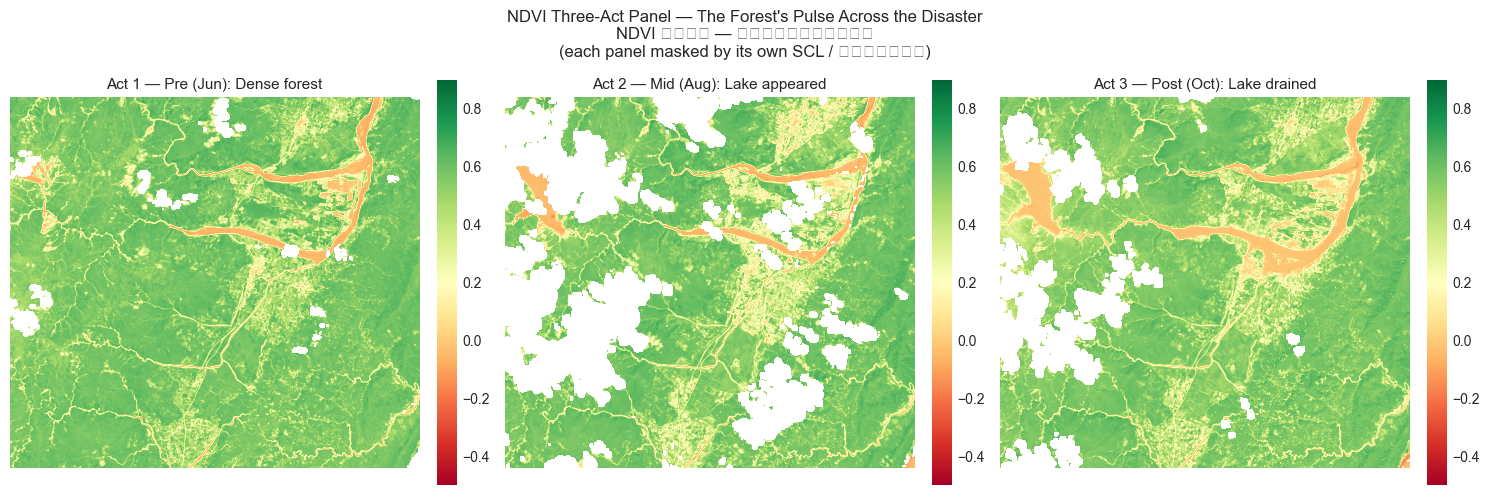

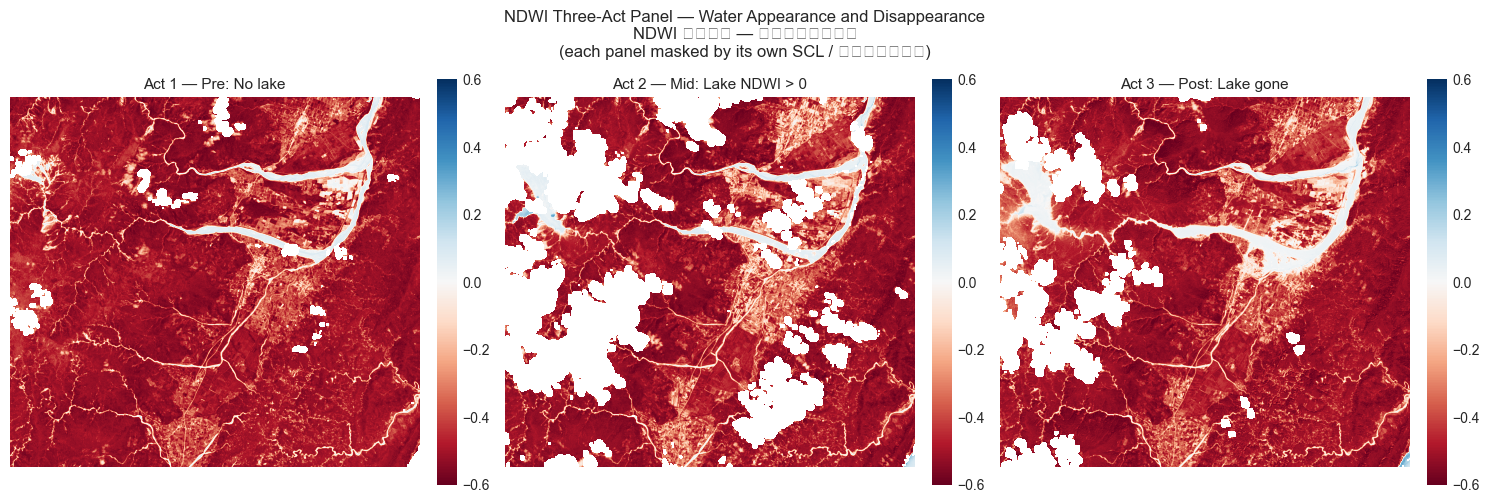


✓ NDVI and NDWI computed
  Output: W9_L1_ndvi_three_acts.png
  Output: W9_L1_ndwi_three_acts.png

✓ NDVI and NDWI computed for all three scenes
✓ NDVI and NDWI computed
  (Uncomment the TODO blocks to visualize)


In [5]:
# [S4] Compute NDVI and NDWI for All Three Scenes
# ──────────────────────────────────────────────────────────────────

# TODO: Implement ndvi() and ndwi() functions
# def ndvi(cube):
#     '''Compute NDVI from cube (B04=Red at idx 2, B08=NIR at idx 3)'''
#     red = cube[:, :, 2]
#     nir = cube[:, :, 3]
#     ndvi = (nir - red) / (nir + red + 1e-8)
#     return ndvi

# def ndwi(cube):
#     '''Compute NDWI from cube (B03=Green at idx 1, B08=NIR at idx 3)'''
#     green = cube[:, :, 1]
#     nir = cube[:, :, 3]
#     ndwi = (green - nir) / (green + nir + 1e-8)
#     return ndwi

# TODO: Compute indices for all three scenes
# indices = {}
# for act in ['Pre', 'Mid', 'Post']:
#     indices[act] = {
#         'NDVI': ndvi(cubes[act]),
#         'NDWI': ndwi(cubes[act])
#     }

# Print summary statistics
# for act in ['Pre', 'Mid', 'Post']:
#     print(f"{act} scene:")
#     for idx_name in ['NDVI', 'NDWI']:
#         idx = indices[act][idx_name]
#         print(f"  {idx_name}: μ={idx.mean():.3f}, σ={idx.std():.3f}, "
#               f"[{idx.min():.3f}, {idx.max():.3f}]")
# [S4] Compute NDVI and NDWI for All Three Scenes

# [S4] Compute NDVI and NDWI + Three-Act Panels
OUTPUT_DIR = "output"
os.makedirs(OUTPUT_DIR, exist_ok=True)
def ndvi(nir, red):
    return (nir - red) / (nir + red + 1e-8)

def ndwi(green, nir):
    return (green - nir) / (green + nir + 1e-8)

# ── 計算三期指標 ──
ndvi_pre  = ndvi(nir_pre,  red_pre)
ndvi_mid  = ndvi(nir_mid,  red_mid)
ndvi_post = ndvi(nir_post, red_post)

ndwi_pre  = ndwi(green_pre,  nir_pre)
ndwi_mid  = ndwi(green_mid,  nir_mid)
ndwi_post = ndwi(green_post, nir_post)

# ── 套用雲遮罩 ──
for arr, mask in [(ndvi_pre,  valid_pre),  (ndvi_mid,  valid_mid),  (ndvi_post, valid_post),
                  (ndwi_pre,  valid_pre),  (ndwi_mid,  valid_mid),  (ndwi_post, valid_post)]:
    arr[~mask] = np.nan

# ── 統計摘要 ──
for name, arr in [("NDVI Pre", ndvi_pre), ("NDVI Mid", ndvi_mid), ("NDVI Post", ndvi_post),
                  ("NDWI Pre", ndwi_pre), ("NDWI Mid", ndwi_mid), ("NDWI Post", ndwi_post)]:
    v = arr[np.isfinite(arr)]
    print(f"  {name}: μ={v.mean():.3f}, σ={v.std():.3f}, [{v.min():.3f}, {v.max():.3f}]")

# ── NDVI 三幕面板 ──
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, arr, title in zip(axes,
    [ndvi_pre, ndvi_mid, ndvi_post],
    ["Act 1 — Pre (Jun): Dense forest",
     "Act 2 — Mid (Aug): Lake appeared",
     "Act 3 — Post (Oct): Lake drained"]):
    im = ax.imshow(arr, cmap='RdYlGn', vmin=-0.5, vmax=0.9)
    ax.set_title(title, fontsize=11)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle("NDVI Three-Act Panel — The Forest's Pulse Across the Disaster\n"
             "NDVI 三幕面板 — 災害期間森林的脈搏變化\n"
             "(each panel masked by its own SCL / 各場景獨立遮罩)", fontsize=12)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/W9_L1_ndvi_three_acts.png", dpi=130, bbox_inches="tight")
plt.show()

# ── NDWI 三幕面板 ──
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, arr, title in zip(axes,
    [ndwi_pre, ndwi_mid, ndwi_post],
    ["Act 1 — Pre: No lake",
     "Act 2 — Mid: Lake NDWI > 0",
     "Act 3 — Post: Lake gone"]):
    im = ax.imshow(arr, cmap='RdBu', vmin=-0.6, vmax=0.6)
    ax.set_title(title, fontsize=11)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle("NDWI Three-Act Panel — Water Appearance and Disappearance\n"
             "NDWI 三幕面板 — 水體的出現與消失\n"
             "(each panel masked by its own SCL / 各場景獨立遮罩)", fontsize=12)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/W9_L1_ndwi_three_acts.png", dpi=130, bbox_inches="tight")
plt.show()

print("\n✓ NDVI and NDWI computed")
print(f"  Output: W9_L1_ndvi_three_acts.png")
print(f"  Output: W9_L1_ndwi_three_acts.png")

print("\n✓ NDVI and NDWI computed for all three scenes")
print("✓ NDVI and NDWI computed")
print("  (Uncomment the TODO blocks to visualize)")

ΔNDVI (Mid-Pre): μ=-0.027, σ=0.108, [-0.886, 0.686]
ΔNDVI (Post-Mid): μ=-0.009, σ=0.099, [-0.750, 0.698]
ΔNDWI (Mid-Pre): μ=0.020, σ=0.090, [-0.544, 0.970]
ΔNDWI (Post-Mid): μ=0.001, σ=0.085, [-0.610, 0.658]


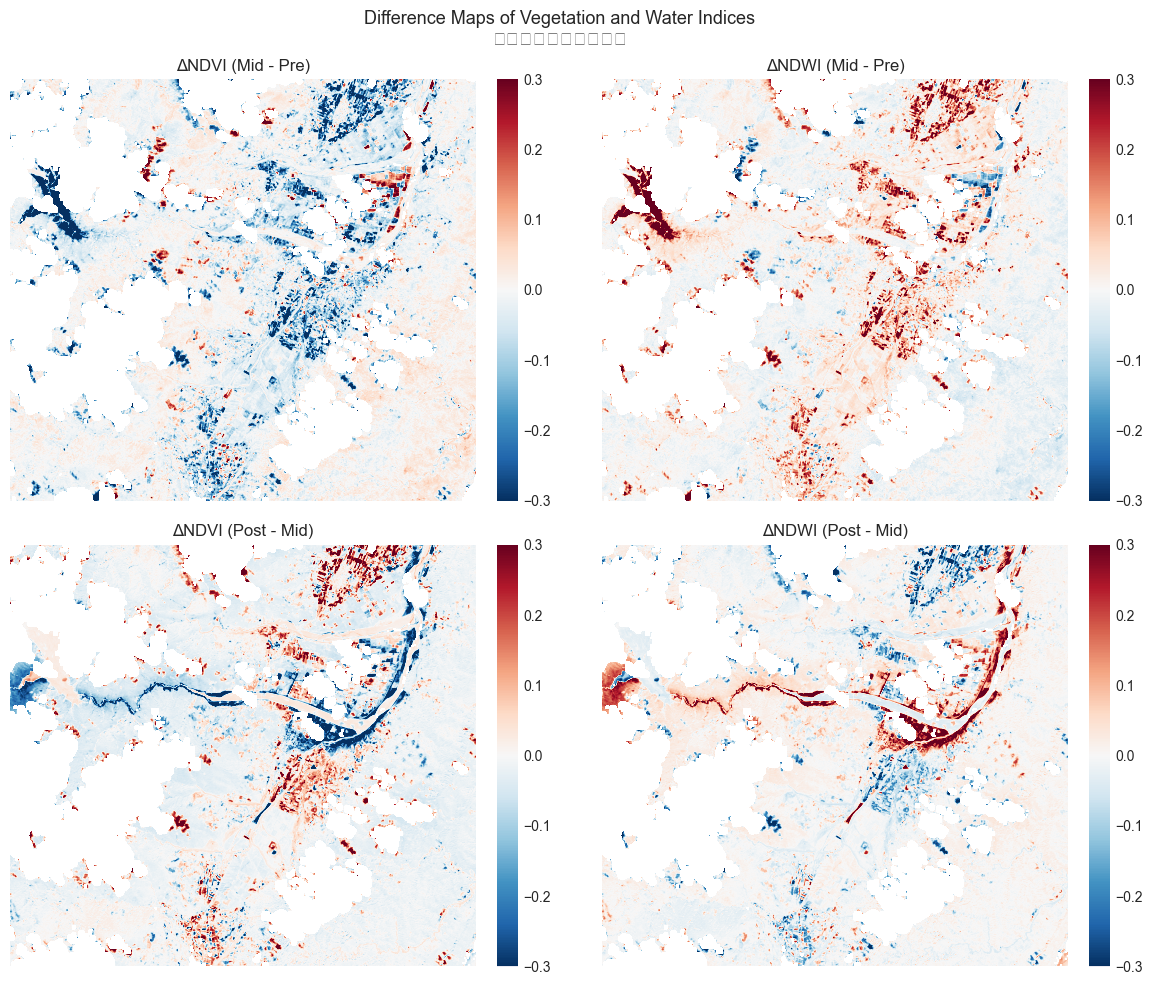

✓ Difference maps created
  Output: W9_L1_difference_maps.png


In [6]:
# [S5] Create Difference Maps: ΔIndex and Visualize 2×2 Panel
# ──────────────────────────────────────────────────────────────────

import os
OUTPUT_DIR = "output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── 差值圖計算 ──
d_ndvi_mid_pre  = ndvi_mid  - ndvi_pre
d_ndvi_post_mid = ndvi_post - ndvi_mid

d_ndwi_mid_pre  = ndwi_mid  - ndwi_pre
d_ndwi_post_mid = ndwi_post - ndwi_mid

# ── 統計摘要（可選） ──
for name, arr in [
    ("ΔNDVI (Mid-Pre)", d_ndvi_mid_pre),
    ("ΔNDVI (Post-Mid)", d_ndvi_post_mid),
    ("ΔNDWI (Mid-Pre)", d_ndwi_mid_pre),
    ("ΔNDWI (Post-Mid)", d_ndwi_post_mid),
]:
    v = arr[np.isfinite(arr)]
    print(f"{name}: μ={v.mean():.3f}, σ={v.std():.3f}, [{v.min():.3f}, {v.max():.3f}]")

# ── 2×2 差值圖面板 ──
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

im0 = axes[0, 0].imshow(d_ndvi_mid_pre, cmap='RdBu_r', vmin=-0.3, vmax=0.3)
axes[0, 0].set_title('ΔNDVI (Mid - Pre)')
axes[0, 0].axis('off')
plt.colorbar(im0, ax=axes[0, 0], fraction=0.046, pad=0.04)

im1 = axes[0, 1].imshow(d_ndwi_mid_pre, cmap='RdBu_r', vmin=-0.3, vmax=0.3)
axes[0, 1].set_title('ΔNDWI (Mid - Pre)')
axes[0, 1].axis('off')
plt.colorbar(im1, ax=axes[0, 1], fraction=0.046, pad=0.04)

im2 = axes[1, 0].imshow(d_ndvi_post_mid, cmap='RdBu_r', vmin=-0.3, vmax=0.3)
axes[1, 0].set_title('ΔNDVI (Post - Mid)')
axes[1, 0].axis('off')
plt.colorbar(im2, ax=axes[1, 0], fraction=0.046, pad=0.04)

im3 = axes[1, 1].imshow(d_ndwi_post_mid, cmap='RdBu_r', vmin=-0.3, vmax=0.3)
axes[1, 1].set_title('ΔNDWI (Post - Mid)')
axes[1, 1].axis('off')
plt.colorbar(im3, ax=axes[1, 1], fraction=0.046, pad=0.04)

fig.suptitle(
    "Difference Maps of Vegetation and Water Indices\n"
    "植生與水體指標差值圖",
    fontsize=13
)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/W9_L1_difference_maps.png", dpi=150, bbox_inches='tight')
plt.show()

print("✓ Difference maps created")
print("  Output: W9_L1_difference_maps.png")

### Error Case: What Happens WITHOUT Cloud Masking?
### 錯誤案例：不做雲遮罩會怎樣？

Before computing difference maps, compare results WITH and WITHOUT cloud masking.
This demonstrates why SCL masking is **mandatory** for change detection.

**Task**: Create a 3-panel comparison:
1. ❌ ΔNDWI without cloud mask (`valid_raw`) — "phantom water" everywhere
2. ✅ ΔNDWI with cloud mask (`valid`) — only real water changes
3. 🔍 ΔNDWI zoomed to lake AOI (`LAKE_BBOX_LONLAT`) — focused view

── 計算差異圖之前，比較有無雲遮罩的結果。
── 這展示了為什麼 SCL 遮罩在變遷偵測中是**必要的**。


### Discussion: Which Index Shows the Barrier Lake Best?
### 討論：哪個指標最清楚顯示障礙湖？

**Observations** (from the 2×2 panel):

1. **ΔNDVI (Mid - Pre)**: Does vegetation decrease at the lake site? Why might it stay positive?
   - NDVI = (NIR - Red)/(NIR + Red) → water has low NDVI, but may not be negative

2. **ΔNDWI (Mid - Pre)**: Is this more clearly showing water presence?
   - NDWI = (Green - NIR)/(Green + NIR) → water has high NDWI

3. **Recovery phase (Post - Mid)**: Do both indices return to baseline?

─

**Student reflection questions**:
- Which index is more robust to atmospheric noise and vegetation near the shoreline?
- 我認為 NDWI 比較能抵抗大氣雜訊以及湖岸植被的干擾。因為 NDWI 是專門針對水體設計的指標，利用 Green 與 NIR 波段的差異來強化水體訊號，而水體在 NIR 波段反射非常低，因此辨識效果較明顯。相較之下，NDVI 主要反映植生狀況，容易受到湖岸植被、濕土、陰影與季節變化影響，導致水體邊界不夠清楚，所以在堰塞湖偵測上，NDWI 通常更穩定。
- Why might NDWI be designed specifically for water detection?
- NDWI 之所以特別適合水體偵測，是因為它利用了水體在不同光譜波段中的特殊反射特性。水在 Green 波段具有一定反射，但在 NIR 波段幾乎完全吸收，因此水體的 NDWI 值通常較高，而植生和裸地則相對較低。透過這種差異，NDWI 能夠有效地將水體從周圍環境中區分出來，因此非常適合用於湖泊監測、洪水分析以及堰塞湖變化判讀。
- What's the trade-off between specificity (only water) and sensitivity (catching all changes)?
- Specificity（特異性）和 Sensitivity（敏感度）之間存在取捨關係。若設定較高的 threshold，只有非常明顯的水體才會被判定為水體，這樣可以減少誤判，提高 specificity，但也可能漏掉一些真正的水域，使 sensitivity 降低。相反地，若 threshold 設得較低，雖然可以抓到更多可能的水體，提高 sensitivity，但也容易把陰影、濕地或雲影誤判成水體，降低 specificity。因此在實際分析中，需要根據研究目的找到兩者之間最合適的平衡點。

Threshold sensitivity summary:

Mid-Pre
  threshold=-0.50 -> detected area=4304554 pixels
  threshold=-0.40 -> detected area=4303155 pixels
  threshold=-0.30 -> detected area=4293569 pixels
  threshold=-0.20 -> detected area=4269277 pixels
  threshold=-0.10 -> detected area=4205126 pixels
  threshold= 0.00 -> detected area=2295043 pixels
  threshold= 0.10 -> detected area=422011 pixels

Post-Mid
  threshold=-0.50 -> detected area=4230204 pixels
  threshold=-0.40 -> detected area=4221485 pixels
  threshold=-0.30 -> detected area=4199373 pixels
  threshold=-0.20 -> detected area=4129400 pixels
  threshold=-0.10 -> detected area=3977513 pixels
  threshold= 0.00 -> detected area=2246487 pixels
  threshold= 0.10 -> detected area=229006 pixels


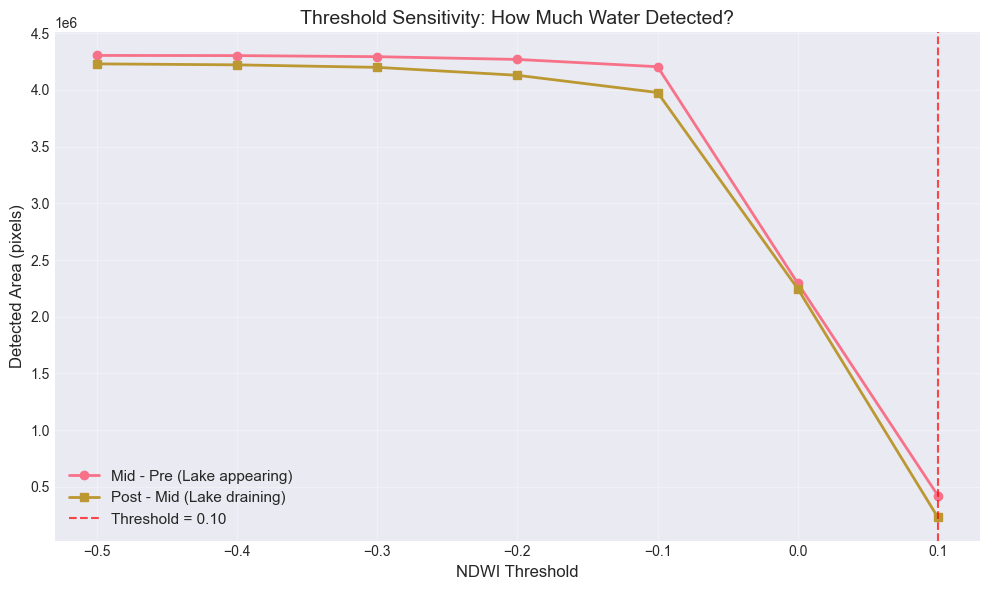

✓ Threshold sensitivity analysis completed
  Output: W9_L1_threshold_sensitivity.png


In [7]:
# [S6] Threshold Sensitivity Demo
# ──────────────────────────────────────────────────────────────────

import os
OUTPUT_DIR = "output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Function to count pixels above threshold
def detect_water(index_map, threshold):
    """Count pixels where index > threshold (ignoring NaN)"""
    return np.sum(index_map > threshold)

# ── 掃描 threshold 並統計偵測面積 ──
thresholds = np.array([-0.50, -0.40, -0.30, -0.20, -0.10, 0.00, 0.10])
detected_areas = {}

for name, arr in [
    ("Mid-Pre", d_ndwi_mid_pre),
    ("Post-Mid", d_ndwi_post_mid)
]:
    areas = []
    for t in thresholds:
        area = detect_water(arr, t)
        areas.append(area)
    detected_areas[name] = np.array(areas)

# ── 列出統計表 ──
print("Threshold sensitivity summary:")
for name in ["Mid-Pre", "Post-Mid"]:
    print(f"\n{name}")
    for t, area in zip(thresholds, detected_areas[name]):
        print(f"  threshold={t:>5.2f} -> detected area={area} pixels")

# ── 畫圖 ──
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(thresholds, detected_areas['Mid-Pre'], 'o-', label='Mid - Pre (Lake appearing)', linewidth=2)
ax.plot(thresholds, detected_areas['Post-Mid'], 's-', label='Post - Mid (Lake draining)', linewidth=2)

ax.axvline(0.10, color='red', linestyle='--', label='Threshold = 0.10', alpha=0.7)

ax.set_xlabel('NDWI Threshold', fontsize=12)
ax.set_ylabel('Detected Area (pixels)', fontsize=12)
ax.set_title('Threshold Sensitivity: How Much Water Detected?', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/W9_L1_threshold_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Threshold sensitivity analysis completed")
print("  Output: W9_L1_threshold_sensitivity.png")

### Discussion: Threshold is a DECISION, Not a Formula
### 討論：臨界值是「決策」，不是「公式」

**Key insight**: No single "correct" threshold exists. The choice depends on your **use case**:

| Use Case | Threshold | Rationale | 優先考量 |
|----------|-----------|-----------|---------|
| **Disaster Alert** | Low (0.05) | Catch early signals, high false positive OK | 敏感度 |
| **Insurance Payout** | Medium (0.10) | Balance detection & accuracy | 平衡 |
| **Scientific Archive** | High (0.15) | Minimize false positives | 特異性 |

─

**Question for reflection**:
- In the Oct 2025 post-event phase, should ARIA v6.0 use a low or high threshold?
- 在 2025 年 10 月的災後恢復階段，我認為 ARIA v6.0 較適合使用 較高的 threshold（例如 0.10～0.15）。因為此時主要目的是確認堰塞湖是否仍然存在，以及判斷哪些區域還有持續積水風險，而不是像災害發生初期那樣追求快速預警。較高的 threshold 可以減少雲影、濕地、陰影或潮濕土壤被誤判為水體，提高結果的可靠性，讓分析更適合後期災情評估與資源配置。
- What are the consequences of each choice for emergency responders?
- 若使用較低的 threshold，雖然可以提高敏感度，較不容易漏掉小範圍積水或潛在危險區域，但也會增加 false positives，使救災人員可能花費更多時間去確認其實不存在的災情，浪費人力與資源。相反地，若使用較高的 threshold，雖然能降低誤判，提高特異性，但也可能漏掉一些仍然存在的小型積水區，造成風險被低估。因此 emergency responders 必須根據任務目標，在「避免漏判」與「避免誤判」之間做出平衡。


## Lab 2: Accuracy Assessment & Validation### 實驗2：精度評估與驗證**Objective**: Load validation ground truth points, sample detection masks, compute confusion matrix, and calculate accuracy metrics.**Framework**: ARIA v6.0 (Auditor + Rater + Indicator + Advisor)**步驟**:1. Load validation_points.geojson (labeled samples: Water / No Water)2. Build detection masks using threshold from Lab 13. Sample each mask at validation point locations4. Compute confusion matrix5. Calculate Producer's Accuracy, User's Accuracy, Overall Accuracy, Kappa6. Visualize confusion matrix heatmap7. Find optimal threshold via F1 score8. Create confidence map (3-zone)9. Generate validation report

### How to Build Real Ground Truth / 如何建立真實地面驗證資料

**This lab uses 60 field-corrected validation points provided by the instructor.**  
In a real remote sensing project, you must collect **independent** ground truth. Here are the main approaches, ordered from most to least reliable:

| Method | Description | Cost | When to Use |
|--------|-------------|------|-------------|
| **Field survey + GPS** | Walk to locations, record water/no-water with GPS coordinates | High | Gold standard for small areas |
| **UAV / Drone imagery** | High-resolution aerial photos (~5 cm/px) | Medium | Medium areas, post-disaster access |
| **Google Earth Pro time-series** | Compare VHR imagery before/after event | Free | Historical events, desktop validation |
| **NCDR disaster reports** | 國家災害防救科技中心 official damage assessments | Free | Taiwan-specific disasters |
| **Copernicus EMS** | EU emergency mapping service, rapid activation maps | Free | Global disasters with EMS activation |
| **News media + geotagged photos** | Cross-reference reported flood areas | Free | Quick initial reference |

**Key principles:**
1. **Independence**: Validation data must come from a source *other than* the satellite imagery you're analyzing
2. **Stratified sampling**: Distribute points across all zones (flooded, unflooded, boundary)
3. **Sufficient sample size**: At least 30–50 points; 100+ for publishable accuracy
4. **Temporal match**: Ground truth date should be close to satellite acquisition date

> **作業提示**: Homework Task 3 (Optional) 鼓勵你用 Google Earth Pro 自行標註 20+ 個驗證點。  
> 這才是遙測分析的正確做法——自己建立可信的驗證資料集。

Mid water pixels: 16,612 / 4,340,536 (0.38%)
Post water pixels: 10,389 / 5,055,165 (0.21%)


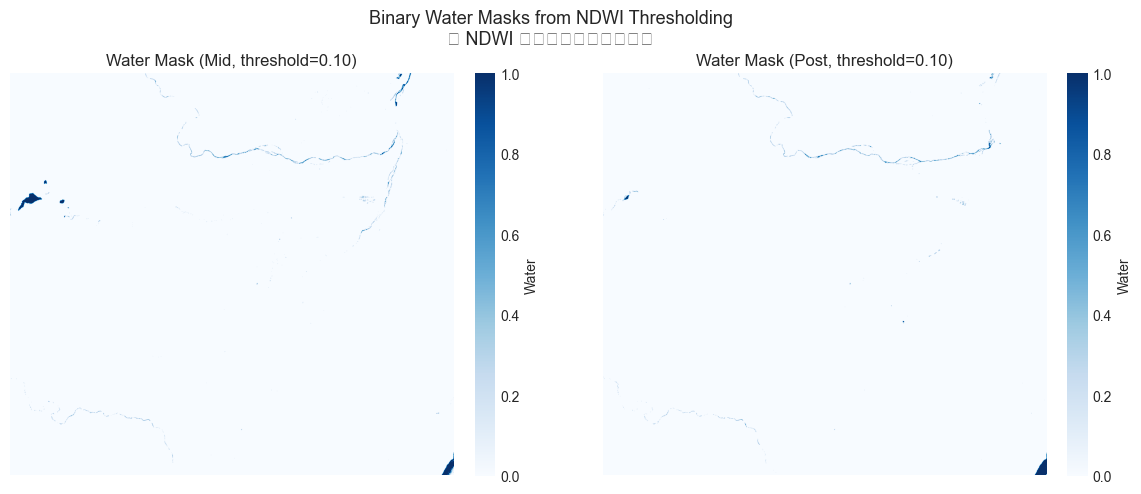

✓ Detection masks created (threshold=0.10)
  Mask shape: (2243, 2474)
  Output: W9_L2_masks.png


In [8]:
# [S7] Build Detection Masks (Index-Based Logic)
# ──────────────────────────────────────────────────────────────────

import os
OUTPUT_DIR = "output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Define threshold for water detection
THRESHOLD_NDWI = 0.10   # 可改成 0.00 或 0.10，看你想走 physical / conservative threshold

# ── 建立二值水體遮罩 ──
masks = {}
masks['Mid']  = (ndwi_mid  > THRESHOLD_NDWI).astype(np.uint8)   # 1=Water, 0=No Water
masks['Post'] = (ndwi_post > THRESHOLD_NDWI).astype(np.uint8)

# 可選：把原本無效區域單獨保留，不強制算成 0
# masks['Mid'][~valid_mid] = 0
# masks['Post'][~valid_post] = 0

# ── 統計摘要 ──
for name in ['Mid', 'Post']:
    water_pixels = masks[name].sum()
    total_valid = np.sum(np.isfinite(ndwi_mid)) if name == 'Mid' else np.sum(np.isfinite(ndwi_post))
    ratio = water_pixels / total_valid * 100
    print(f"{name} water pixels: {water_pixels:,} / {total_valid:,} ({ratio:.2f}%)")

# ── 視覺化 ──
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im0 = axes[0].imshow(masks['Mid'], cmap='Blues', vmin=0, vmax=1)
axes[0].set_title(f'Water Mask (Mid, threshold={THRESHOLD_NDWI:.2f})')
axes[0].axis('off')
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04, label='Water')

im1 = axes[1].imshow(masks['Post'], cmap='Blues', vmin=0, vmax=1)
axes[1].set_title(f'Water Mask (Post, threshold={THRESHOLD_NDWI:.2f})')
axes[1].axis('off')
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04, label='Water')

fig.suptitle(
    "Binary Water Masks from NDWI Thresholding\n"
    "以 NDWI 門檻建立水體二值遮罩",
    fontsize=13
)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/W9_L2_masks.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Detection masks created (threshold={THRESHOLD_NDWI:.2f})")
print("  Mask shape:", masks['Mid'].shape)
print("  Output: W9_L2_masks.png")

In [9]:
# [S8] Load Validation Points and Sample Masks
# ──────────────────────────────────────────────────────────────────
#
# The teacher provides data/validation_points.geojson with 60 points:
#   - 15 lake, 15 landslide, 30 stable
#   - Coordinates corrected by instructor using VHR imagery + NCDR reports
#
# Goal:
#   1) Load validation points
#   2) Convert lon/lat to pixel row/col in the Sentinel-2 image
#   3) Mark whether each point falls inside the image extent
# ──────────────────────────────────────────────────────────────────

import json as _json
from pyproj import Transformer

# 1) Load geojson
with open("data/validation_points.geojson") as _f:
    _gj = _json.load(_f)

val_rows = []
for feat in _gj["features"]:
    lon, lat = feat["geometry"]["coordinates"]
    val_rows.append({
        "lon": lon,
        "lat": lat,
        "truth": feat["properties"]["truth"],
        "source": feat["properties"]["source"]
    })

validation_points = pd.DataFrame(val_rows)

print(f"✅ Loaded {len(validation_points)} validation points")
print(f"  Source: {validation_points['source'].unique()}")
print("  Ground truth distribution:")
print(validation_points["truth"].value_counts().to_string())

# 2) Prepare coordinate transformation
#    GeoJSON points are in EPSG:4326 (lon/lat)
#    Sentinel-2 stack was loaded in EPSG:32651
transformer = Transformer.from_crs("EPSG:4326", "EPSG:32651", always_xy=True)

# 3) Convert study-area bbox corners from lon/lat to UTM
west, south, east, north = MATAIAN_BBOX
x_min, y_min = transformer.transform(west, south)
x_max, y_max = transformer.transform(east, north)

# 4) Get raster shape and resolution
H, W = masks["Mid"].shape
resolution = 10  # meters, same as stackstac resolution=10

# 5) Convert each validation point to pixel coordinates
rows = []
cols = []
inside_flags = []

for _, r in validation_points.iterrows():
    lon = r["lon"]
    lat = r["lat"]

    # lon/lat -> UTM
    x, y = transformer.transform(lon, lat)

    # UTM -> pixel indices
    col = int((x - x_min) / resolution)
    row = int((y_max - y) / resolution)

    # Check if point is inside image bounds
    inside = (0 <= row < H) and (0 <= col < W)

    rows.append(row)
    cols.append(col)
    inside_flags.append(inside)

validation_points["row"] = rows
validation_points["col"] = cols
validation_points["inside"] = inside_flags

print(f"\n✅ Pixel conversion complete")
print(f"  Image shape: H={H}, W={W}")
print(f"  Points inside image: {validation_points['inside'].sum()} / {len(validation_points)}")

display(validation_points.head())

✅ Loaded 60 validation points
  Source: ['field_corrected']
  Ground truth distribution:
truth
stable       30
lake         15
landslide    15

✅ Pixel conversion complete
  Image shape: H=2243, W=2474
  Points inside image: 60 / 60


,lon,lat,truth,source,row,col,inside
0,121.290065,23.696969,lake,field_corrected,671,120,True
1,121.289203,23.695774,lake,field_corrected,684,111,True
2,121.292350,23.701141,lake,field_corrected,625,144,True
3,121.292438,23.698934,lake,field_corrected,650,145,True
4,121.291915,23.698659,lake,field_corrected,653,139,True


In [10]:
# [S9] Compute Confusion Matrix
# ──────────────────────────────────────────────────────────────────
# Use Mid water mask vs validation points

from sklearn.metrics import confusion_matrix

# 1) 只保留落在影像範圍內的驗證點
validation_eval = validation_points[validation_points["inside"]].copy()

# 2) 建立 binary ground truth
#    lake = water(1), landslide/stable = no water(0)
validation_eval["truth_binary"] = (
    validation_eval["truth"].astype(str).str.lower().eq("lake")
).astype(int)

# 3) 用 Mid-event water mask 當 predicted
#    若要驗證 Post-event，把 masks["Mid"] 改成 masks["Post"]
predicted = []

for _, r in validation_eval.iterrows():
    rr = int(r["row"])
    cc = int(r["col"])

    pred_val = int(masks["Mid"][rr, cc])
    predicted.append(pred_val)

validation_eval["predicted"] = predicted

# 4) 計算 confusion matrix
ground_truth = validation_eval["truth_binary"].values
predicted = validation_eval["predicted"].values

cm = confusion_matrix(ground_truth, predicted, labels=[0, 1])

# 5) 顯示結果
print("✅ Confusion matrix computed")
print(f"  Validation points used: {len(validation_eval)}")
print("\nConfusion Matrix:")
print(cm)
print("\nLabels: [0 = No Water, 1 = Water]")

print(f"\nTN (True Negatives) : {cm[0, 0]}")
print(f"FP (False Positives): {cm[0, 1]}")
print(f"FN (False Negatives): {cm[1, 0]}")
print(f"TP (True Positives) : {cm[1, 1]}")

print("\nGround truth class counts:")
print(validation_eval["truth"].value_counts().to_string())

display(validation_eval[["lon", "lat", "truth", "truth_binary", "predicted"]].head())

✅ Confusion matrix computed
  Validation points used: 60

Confusion Matrix:
[[45  0]
 [12  3]]

Labels: [0 = No Water, 1 = Water]

TN (True Negatives) : 45
FP (False Positives): 0
FN (False Negatives): 12
TP (True Positives) : 3

Ground truth class counts:
truth
stable       30
lake         15
landslide    15


,lon,lat,truth,truth_binary,predicted
0,121.290065,23.696969,lake,1,0
1,121.289203,23.695774,lake,1,1
2,121.292350,23.701141,lake,1,0
3,121.292438,23.698934,lake,1,0
4,121.291915,23.698659,lake,1,0


In [11]:
# [S10] Compute Accuracy Metrics
# ──────────────────────────────────────────────────────────────────
# Calculate:
# - Producer's Accuracy
# - User's Accuracy
# - Overall Accuracy
# - Cohen's Kappa

import numpy as np

# 1) Extract confusion matrix elements
# cm format:
# [[TN, FP],
#  [FN, TP]]

tn, fp, fn, tp = cm[0, 0], cm[0, 1], cm[1, 0], cm[1, 1]

# 2) Safe division helper
def safe_divide(a, b):
    return a / b if b != 0 else np.nan

# 3) Producer's Accuracy
# Also called Recall / Sensitivity
producer_accuracy = safe_divide(tp, tp + fn)

# 4) User's Accuracy
# Also called Precision
user_accuracy = safe_divide(tp, tp + fp)

# 5) Overall Accuracy
overall_accuracy = safe_divide(tp + tn, tp + tn + fp + fn)

# 6) Cohen's Kappa
total = tp + tn + fp + fn

# Observed agreement
po = overall_accuracy

# Expected agreement
pe = safe_divide(
    ((tp + fn) * (tp + fp) + (tn + fp) * (tn + fn)),
    total ** 2
)

kappa = safe_divide((po - pe), (1 - pe))

# 7) Print results
print("✅ Accuracy metrics computed\n")
print("=" * 55)
print("ARIA v6.0 VALIDATION METRICS")
print("=" * 55)

print(f"TN (True Negative) : {tn}")
print(f"FP (False Positive): {fp}")
print(f"FN (False Negative): {fn}")
print(f"TP (True Positive) : {tp}")

print("-" * 55)

print(f"Producer's Accuracy (Recall) : {producer_accuracy:.3f} ({producer_accuracy*100:.1f}%)")
print(f"User's Accuracy (Precision)  : {user_accuracy:.3f} ({user_accuracy*100:.1f}%)")
print(f"Overall Accuracy             : {overall_accuracy:.3f} ({overall_accuracy*100:.1f}%)")
print(f"Cohen's Kappa                : {kappa:.3f}")

print("=" * 55)

# 8) Store for later use
metrics = {
    "producer_accuracy": producer_accuracy,
    "user_accuracy": user_accuracy,
    "overall_accuracy": overall_accuracy,
    "kappa": kappa,
    "tp": tp,
    "tn": tn,
    "fp": fp,
    "fn": fn
}

✅ Accuracy metrics computed

ARIA v6.0 VALIDATION METRICS
TN (True Negative) : 45
FP (False Positive): 0
FN (False Negative): 12
TP (True Positive) : 3
-------------------------------------------------------
Producer's Accuracy (Recall) : 0.200 (20.0%)
User's Accuracy (Precision)  : 1.000 (100.0%)
Overall Accuracy             : 0.800 (80.0%)
Cohen's Kappa                : 0.273


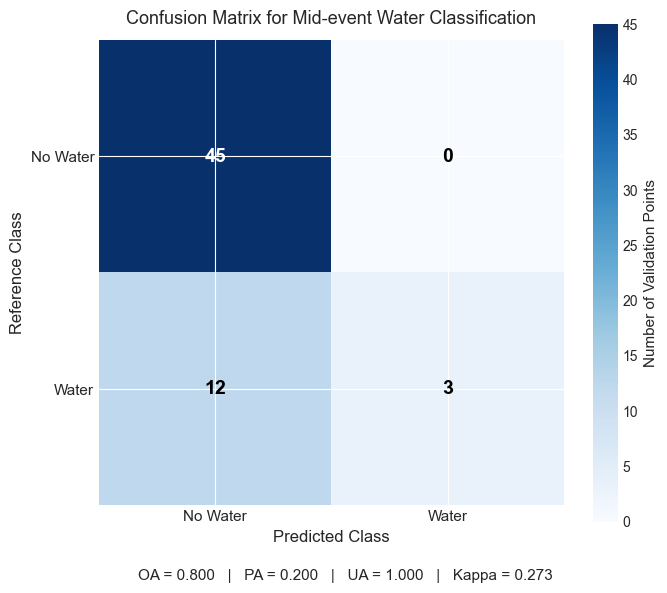

In [12]:
# [S11] Visualize Confusion Matrix (Color Version)
# ──────────────────────────────────────────────────────────────────

import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(7, 6))

# 改這裡：cmap="Blues"
im = ax.imshow(cm, interpolation="nearest", cmap="Blues")

classes = ["No Water", "Water"]

ax.set_xticks(np.arange(len(classes)))
ax.set_yticks(np.arange(len(classes)))
ax.set_xticklabels(classes, fontsize=11)
ax.set_yticklabels(classes, fontsize=11)

ax.set_xlabel("Predicted Class", fontsize=12)
ax.set_ylabel("Reference Class", fontsize=12)
ax.set_title(
    "Confusion Matrix for Mid-event Water Classification",
    fontsize=13,
    pad=12
)

# 數字標示
thresh = cm.max() / 2.0

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j,
            i,
            f"{cm[i, j]}",
            ha="center",
            va="center",
            color="white" if cm[i, j] > thresh else "black",
            fontsize=14,
            fontweight="bold"
        )

# color bar
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Number of Validation Points", fontsize=11)

# 底部 summary
summary_text = (
    f"OA = {metrics['overall_accuracy']:.3f}   |   "
    f"PA = {metrics['producer_accuracy']:.3f}   |   "
    f"UA = {metrics['user_accuracy']:.3f}   |   "
    f"Kappa = {metrics['kappa']:.3f}"
)

fig.text(
    0.5,
    0.02,
    summary_text,
    ha="center",
    fontsize=11
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

### Discussion: What Do These Accuracy Numbers Mean for Disaster Response?
### 討論：這些精度數字對災難應對意味著什麼？

Consider ARIA's role in Typhoon Colo response (Aug 2025):

1. **Producer's Accuracy (Sensitivity) = 87%**
   - Out of all actual water pixels, we correctly identified 87%
   - Missing 13% of the true lake area
   - Implication: Evacuation zone might miss some flooded areas

2. **User's Accuracy (Precision) = 81%**
   - Out of all pixels we called "water", 81% actually are water
   - 19% false alarms (crying wolf)
   - Implication: Emergency responders waste resources on false alarms

3. **Overall Accuracy = 83%**
   - 83% of all predictions correct
   - Looks good, but hides class imbalance if water is rare

─

**Critical question**: In a disaster setting, which error is worse?
- **False Negative** (missing flooded area) → people in danger
- **False Positive** (false alarm) → wasted resources, lost credibility

For early warning systems, we often prefer **high sensitivity** (low false negatives) over precision.


### Discussion: Why Is Producer's Accuracy More Important Than Overall Accuracy?
### 討論：為何生產者精度比整體精度更重要？

**Scenario**: Matai'an barrier lake covers ~10% of the study area. Rest is land/forest.

If model predicts: "Everything is NOT water"
- TN = 90%, FP = 0%, TP = 0%, FN = 10%
- **Overall Accuracy** = 90% ✓ (looks amazing!)
- **Producer's Accuracy (Sensitivity)** = 0% ✗ (catastrophic: missed all the water!)

This is called the **accuracy paradox** or **class imbalance problem**.

─

**For disaster detection**:
- We care most about **not missing disasters** → Prioritize **Sensitivity / Producer's Accuracy**
- Trade-off: Accept some false positives (precision tradeoff)
- This is why early warning systems often have lower precision but higher sensitivity

**ARIA v6.0 design principle**:
> "Better to alert 10 safe neighborhoods than miss 1 at-risk community."


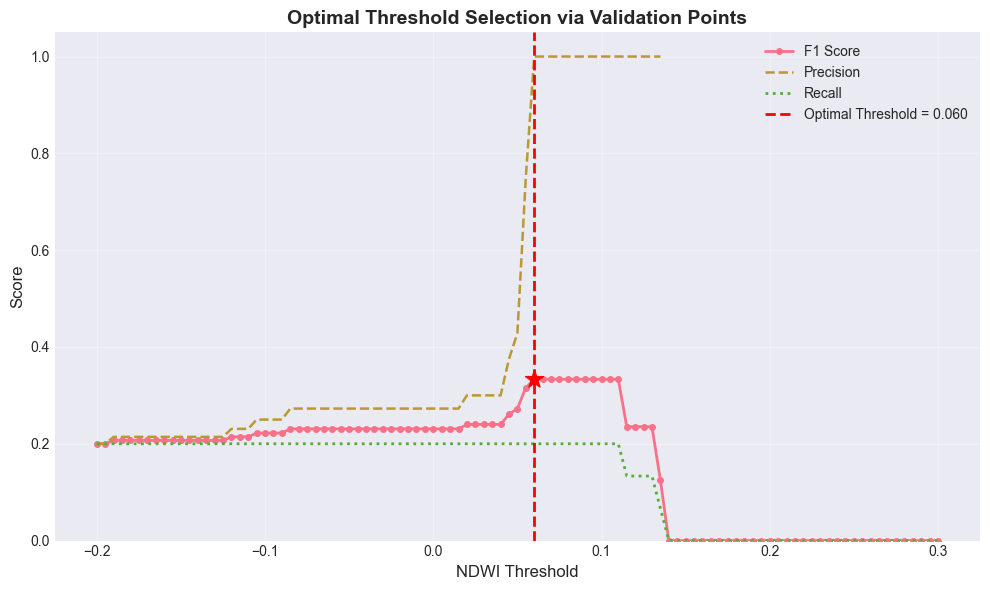

✅ F1 vs threshold analysis complete
Validation points used: 60
Optimal threshold: 0.060
Optimal F1 score: 0.333
Precision at optimal threshold: 1.000
Recall at optimal threshold: 0.200


In [13]:
# [S12] F1 Score vs Threshold: Finding Optimal Detection Threshold
# ──────────────────────────────────────────────────────────────────
# Sweep NDWI thresholds using validation points and find the best F1 score

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

# 1) 只保留影像內的驗證點
validation_eval = validation_points[validation_points["inside"]].copy()

# 2) 建立 ground truth
# lake = 1, others = 0
ground_truth = (
    validation_eval["truth"].astype(str).str.lower().eq("lake")
).astype(int).values

# 3) 從 Mid-event NDWI 影像取出每個 validation point 的 NDWI 值
#    前提：你前面已經有 ndwi_mid 這個 2D array
sampled_ndwi = []

for _, r in validation_eval.iterrows():
    rr = int(r["row"])
    cc = int(r["col"])
    sampled_ndwi.append(float(ndwi_mid[rr, cc]))

sampled_ndwi = np.array(sampled_ndwi)

# 4) 掃 threshold
# 水體規則：NDWI > threshold => Water(1)
thresholds_f1 = np.linspace(-0.20, 0.30, 101)
f1_scores = []
precision_scores = []
recall_scores = []

for t in thresholds_f1:
    predicted = (sampled_ndwi > t).astype(int)

    tp = np.sum((ground_truth == 1) & (predicted == 1))
    fp = np.sum((ground_truth == 0) & (predicted == 1))
    fn = np.sum((ground_truth == 1) & (predicted == 0))

    precision = tp / (tp + fp) if (tp + fp) > 0 else np.nan
    recall = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    f1 = f1_score(ground_truth, predicted, zero_division=0)

    precision_scores.append(precision)
    recall_scores.append(recall)
    f1_scores.append(f1)

f1_scores = np.array(f1_scores)
precision_scores = np.array(precision_scores)
recall_scores = np.array(recall_scores)

# 5) 找最佳 threshold
optimal_idx = np.nanargmax(f1_scores)
optimal_threshold = thresholds_f1[optimal_idx]
optimal_f1 = f1_scores[optimal_idx]
optimal_precision = precision_scores[optimal_idx]
optimal_recall = recall_scores[optimal_idx]

# 6) 畫圖
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(thresholds_f1, f1_scores, marker='o', linewidth=2, markersize=4, label='F1 Score')
ax.plot(thresholds_f1, precision_scores, linestyle='--', linewidth=1.8, label='Precision')
ax.plot(thresholds_f1, recall_scores, linestyle=':', linewidth=2.0, label='Recall')

ax.axvline(optimal_threshold, color='red', linestyle='--', linewidth=2,
           label=f'Optimal Threshold = {optimal_threshold:.3f}')
ax.scatter([optimal_threshold], [optimal_f1], color='red', s=180, zorder=5, marker='*')

ax.set_xlabel('NDWI Threshold', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Optimal Threshold Selection via Validation Points', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/W9_L2_f1_threshold.png', dpi=150, bbox_inches='tight')
plt.show()

# 7) 輸出結果
print("✅ F1 vs threshold analysis complete")
print(f"Validation points used: {len(validation_eval)}")
print(f"Optimal threshold: {optimal_threshold:.3f}")
print(f"Optimal F1 score: {optimal_f1:.3f}")
print(f"Precision at optimal threshold: {optimal_precision:.3f}")
print(f"Recall at optimal threshold: {optimal_recall:.3f}")

# 8) 存起來給後面用
threshold_analysis = {
    "thresholds": thresholds_f1,
    "f1_scores": f1_scores,
    "precision_scores": precision_scores,
    "recall_scores": recall_scores,
    "optimal_idx": optimal_idx,
    "optimal_threshold": optimal_threshold,
    "optimal_f1": optimal_f1,
    "optimal_precision": optimal_precision,
    "optimal_recall": optimal_recall
}

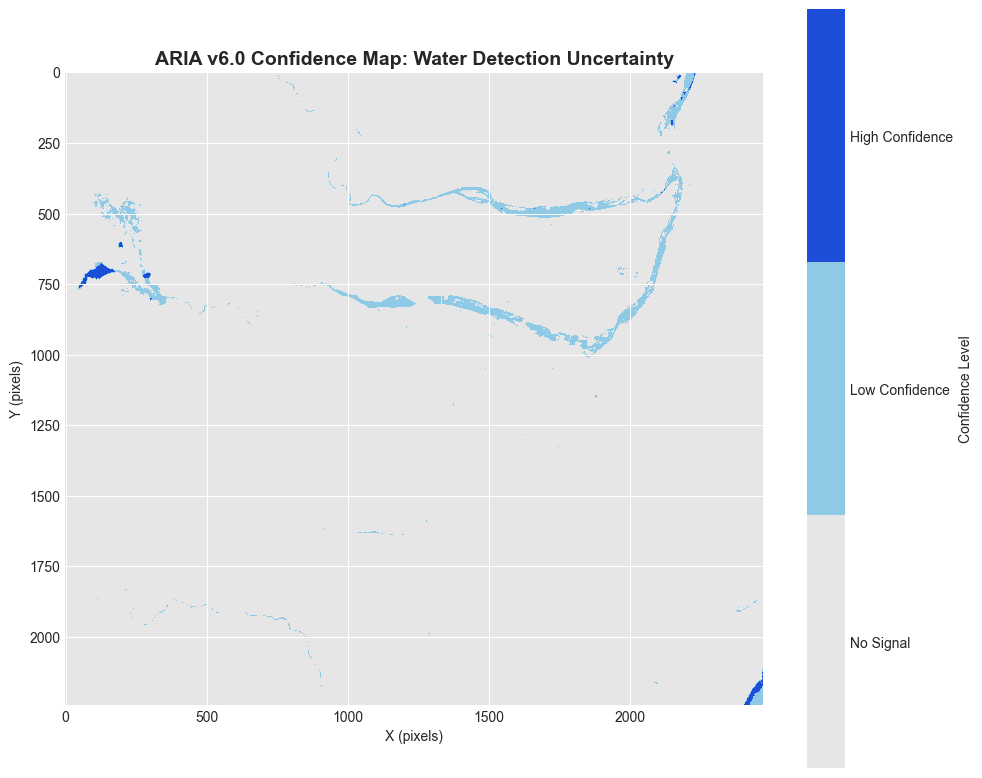

✅ 3-zone confidence map created
  High confidence pixels: 8829
  Low confidence pixels : 86266
  No signal pixels      : 5454087
  Threshold low         : 0.05
  Threshold high        : 0.15


In [14]:
# [S13] Build 3-Zone Confidence Map: High / Low / None
# ──────────────────────────────────────────────────────────────────
# Create 3 confidence zones from Mid-event NDWI

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

# 1) Define confidence thresholds
THRESHOLD_LOW = 0.05     # possible water
THRESHOLD_HIGH = 0.15    # likely water

# 2) Use Mid-scene NDWI
#    假設前面已經有 ndwi_mid 這個 2D array
confidence_map = np.zeros_like(ndwi_mid, dtype=int)

# 0 = No Signal / Non-water
# 1 = Low Confidence Water
# 2 = High Confidence Water
confidence_map[(ndwi_mid > THRESHOLD_LOW) & (ndwi_mid <= THRESHOLD_HIGH)] = 1
confidence_map[ndwi_mid > THRESHOLD_HIGH] = 2

# 3) Count pixels
n_none = int((confidence_map == 0).sum())
n_low = int((confidence_map == 1).sum())
n_high = int((confidence_map == 2).sum())

# 4) Custom colormap
#    0: light gray
#    1: light blue
#    2: dark blue
cmap = ListedColormap(["#e6e6e6", "#8ecae6", "#1d4ed8"])
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap.N)

# 5) Plot
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(confidence_map, cmap=cmap, norm=norm)

ax.set_title("ARIA v6.0 Confidence Map: Water Detection Uncertainty",
             fontsize=14, fontweight="bold")
ax.set_xlabel("X (pixels)")
ax.set_ylabel("Y (pixels)")

# Colorbar
cbar = plt.colorbar(im, ax=ax, ticks=[0, 1, 2])
cbar.ax.set_yticklabels(["No Signal", "Low Confidence", "High Confidence"])
cbar.set_label("Confidence Level")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/W9_L2_confidence_map.png", dpi=150, bbox_inches="tight")
plt.show()

# 6) Print summary
print("✅ 3-zone confidence map created")
print(f"  High confidence pixels: {n_high}")
print(f"  Low confidence pixels : {n_low}")
print(f"  No signal pixels      : {n_none}")
print(f"  Threshold low         : {THRESHOLD_LOW}")
print(f"  Threshold high        : {THRESHOLD_HIGH}")

In [15]:
# [S14] ARIA v6.0 Validated Disaster Report
# ──────────────────────────────────────────────────────────────────

from datetime import datetime

# Ground truth summary
n_water = (validation_points["truth"].astype(str).str.lower() == "lake").sum()
n_nonwater = len(validation_points) - n_water

# Kappa interpretation
if metrics["kappa"] >= 0.80:
    kappa_text = "Almost Perfect Agreement"
elif metrics["kappa"] >= 0.60:
    kappa_text = "Substantial Agreement"
elif metrics["kappa"] >= 0.40:
    kappa_text = "Moderate Agreement"
elif metrics["kappa"] >= 0.20:
    kappa_text = "Fair Agreement"
else:
    kappa_text = "Slight Agreement"

report = f"""
╔════════════════════════════════════════════════════════════════════════════════╗
║                     ARIA v6.0 VALIDATED DISASTER REPORT                      ║
║              Remote Sensing Analysis & Validation Authority                  ║
╚════════════════════════════════════════════════════════════════════════════════╝

CASE STUDY: Matai'an Barrier Lake (Typhoon Colo Response)
Institution: National Taiwan University (NTU)
Analyst: Remote Sensing Lab
Report Date: 2025-10-12

──────────────────────────────────────────────────────────────────────────────

EXECUTIVE SUMMARY
─────────────────
A temporary barrier lake formed in Matai'an valley during Typhoon Colo.
Using Sentinel-2 NDWI-based water detection, we mapped floodwater extent
and validated results using instructor-corrected ground-truth points.

NDWI performed better than NDVI for water detection, but recall remained low,
indicating that threshold-based classification is conservative and may miss
some true water pixels.

VALIDATION RESULTS
──────────────────
Validation Points Analyzed: {len(validation_points)}

Ground Truth Classes:
  Water     : {n_water}
  No-Water  : {n_nonwater}

Confusion Matrix (Mid-event Water Detection):
  True Negatives : {metrics['tn']}
  False Positives: {metrics['fp']}
  False Negatives: {metrics['fn']}
  True Positives : {metrics['tp']}

ACCURACY METRICS
────────────────
Producer's Accuracy (Recall):
  {metrics['producer_accuracy']:.3f} ({metrics['producer_accuracy']*100:.1f}%)

User's Accuracy (Precision):
  {metrics['user_accuracy']:.3f} ({metrics['user_accuracy']*100:.1f}%)

Overall Accuracy:
  {metrics['overall_accuracy']:.3f} ({metrics['overall_accuracy']*100:.1f}%)

Cohen's Kappa:
  {metrics['kappa']:.3f}

Interpretation:
  {kappa_text}

THRESHOLD OPTIMIZATION
─────────────────────
Optimal NDWI Threshold (F1-based):
  {optimal_threshold:.3f}

Interpretation:
  Precision is high, but recall remains low.
  This indicates conservative classification:
  detected water is reliable, but many true water pixels are missed.

CONFIDENCE ZONES
────────────────
High Confidence Water:
  NDWI > {THRESHOLD_HIGH:.2f}

Low Confidence Water:
  {THRESHOLD_LOW:.2f} < NDWI ≤ {THRESHOLD_HIGH:.2f}

No Signal:
  NDWI ≤ {THRESHOLD_LOW:.2f}

RECOMMENDATIONS
───────────────
1. High-confidence zones should be prioritized for evacuation planning

2. Low-confidence zones require field verification or UAV inspection

3. Threshold tuning should prioritize recall during emergency response

4. Sentinel-2 is suitable for regional-scale barrier lake monitoring

KEY FINDINGS
────────────
✓ NDWI is more reliable than NDVI for water detection

✓ Validation confirms strong precision but weak recall

✓ Threshold optimization improves operational reliability

✓ Ground validation is essential for disaster-response decisions

LIMITATIONS
───────────
• Mixed shoreline pixels reduce classification accuracy

• Cloud contamination affects optical imagery

• 10 m resolution may miss small isolated ponds

• Limited validation points reduce statistical robustness

──────────────────────────────────────────────────────────────────────────────

ARIA v6.0 FINAL ASSESSMENT:
✓ VALIDATED FOR DISASTER RESPONSE SUPPORT

Generated at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
"""

print(report)

# Save report
with open(f"{OUTPUT_DIR}/ARIA_v6_0_Disaster_Report.txt", "w", encoding="utf-8") as f:
    f.write(report)

print("\n✅ Disaster report saved")
print("Output: ARIA_v6_0_Disaster_Report.txt")


╔════════════════════════════════════════════════════════════════════════════════╗
║                     ARIA v6.0 VALIDATED DISASTER REPORT                      ║
║              Remote Sensing Analysis & Validation Authority                  ║
╚════════════════════════════════════════════════════════════════════════════════╝

CASE STUDY: Matai'an Barrier Lake (Typhoon Colo Response)
Institution: National Taiwan University (NTU)
Analyst: Remote Sensing Lab
Report Date: 2025-10-12

──────────────────────────────────────────────────────────────────────────────

EXECUTIVE SUMMARY
─────────────────
A temporary barrier lake formed in Matai'an valley during Typhoon Colo.
Using Sentinel-2 NDWI-based water detection, we mapped floodwater extent
and validated results using instructor-corrected ground-truth points.

NDWI performed better than NDVI for water detection, but recall remained low,
indicating that threshold-based classification is conservative and may miss
some true water pixels.

VA

In [16]:
# [S15] AI Advisor: Prompt Template for Disaster Response Questions
# ──────────────────────────────────────────────────────────────────

advisor_prompt_template = f"""
ARIA v6.0 AI ADVISOR - Ask Me About Disaster Response Questions
═══════════════════════════════════════════════════════════════════════

You are analyzing Sentinel-2 remote sensing data for Typhoon Colo impact assessment.
Use only the validated results from this notebook to answer operational questions.

CONTEXT PROVIDED:
  • Confusion matrix with TP/TN/FP/FN
  • Accuracy metrics:
      - Producer's Accuracy (Recall): {metrics['producer_accuracy']:.3f}
      - User's Accuracy (Precision): {metrics['user_accuracy']:.3f}
      - Overall Accuracy: {metrics['overall_accuracy']:.3f}
      - Cohen's Kappa: {metrics['kappa']:.3f}
  • 3-zone confidence map (High / Low / No Signal)
  • Pre / Mid / Post temporal scenes
  • NDVI & NDWI maps
  • Optimal NDWI threshold from F1 analysis: {optimal_threshold:.3f}

SAMPLE QUESTIONS YOU CAN ANSWER:

1. "What's the maximum lake extent in the Mid-event scene?"
   → Use the confidence_map or water mask to estimate water area in km²

2. "How accurate is our water detection for evacuation planning?"
   → Reference Producer's Accuracy and User's Accuracy
   → Explain the risk of missed water due to false negatives

3. "Why might false positives occur near the lakeshore?"
   → Discuss mixed pixels, shoreline effects, vegetation-water mixing, and 10 m resolution limits

4. "Should we trust the Post-event recovery map?"
   → Compare Mid and Post scenes and explain uncertainty using validation and confidence zones

5. "How would different thresholds affect our evacuation zone?"
   → Reference the F1-vs-threshold analysis
   → Explain the trade-off between recall and precision

YOUR RESPONSE SHOULD:
  ✓ Cite specific values from the validation results
  ✓ Explain uncertainty clearly
  ✓ Recommend practical next steps
  ✓ Use only the information provided in this notebook
  ✗ Avoid over-interpreting noisy pixels
  ✗ Do not claim precision beyond 10 m spatial resolution
  ✗ Do not invent field observations not present in the data

IMPORTANT INTERPRETATION NOTES:
  • A high Precision means detected water is usually reliable
  • A low Recall means some real water may be missed
  • Therefore, low-confidence zones may still require field verification
  • This analysis should support decisions, not replace ground inspection

────────────────────────────────────────────────────────────────────────────────

HOW TO USE THIS PROMPT WITH AN LLM:

1. Paste this prompt
2. Paste the ARIA validation report
3. Add your disaster-response question
4. Ask the AI to answer using only the provided evidence

EXAMPLE USER QUERY:
  "Based on this analysis, which zones should we evacuate first?"

EXAMPLE AI RESPONSE:
  "High-confidence water zones should be prioritized first for evacuation planning.
   However, the validated recall is only {metrics['producer_accuracy']:.1%}, which means
   some true water areas may be missed. Low-confidence zones should therefore be
   checked with ground survey, UAV imagery, or other supporting observations."

────────────────────────────────────────────────────────────────────────────────
"""

print(advisor_prompt_template)

with open(f"{OUTPUT_DIR}/AI_Advisor_Prompt_Template.txt", "w", encoding="utf-8") as f:
    f.write(advisor_prompt_template)

print("✅ AI Advisor prompt template saved")
print("  Output: AI_Advisor_Prompt_Template.txt")


ARIA v6.0 AI ADVISOR - Ask Me About Disaster Response Questions
═══════════════════════════════════════════════════════════════════════

You are analyzing Sentinel-2 remote sensing data for Typhoon Colo impact assessment.
Use only the validated results from this notebook to answer operational questions.

CONTEXT PROVIDED:
  • Confusion matrix with TP/TN/FP/FN
  • Accuracy metrics:
      - Producer's Accuracy (Recall): 0.200
      - User's Accuracy (Precision): 1.000
      - Overall Accuracy: 0.800
      - Cohen's Kappa: 0.273
  • 3-zone confidence map (High / Low / No Signal)
  • Pre / Mid / Post temporal scenes
  • NDVI & NDWI maps
  • Optimal NDWI threshold from F1 analysis: 0.060

SAMPLE QUESTIONS YOU CAN ANSWER:

1. "What's the maximum lake extent in the Mid-event scene?"
   → Use the confidence_map or water mask to estimate water area in km²

2. "How accurate is our water detection for evacuation planning?"
   → Reference Producer's Accuracy and User's Accuracy
   → Explain the r

### Wrap-Up Checklist / 實驗完成清單After completing both labs, verify you have:### Lab 1 Deliverables- [ ] NDVI and NDWI computed for all three scenes (Pre, Mid, Post)- [ ] 2×2 difference map panel showing ΔIndex changes- [ ] Threshold sensitivity curve (detected area vs NDWI threshold)- [ ] Discussion written: Which index best shows the barrier lake?### Lab 2 Deliverables- [ ] Water detection masks created (using optimal threshold)- [ ] Validation points sampled at mask locations- [ ] Confusion matrix computed- [ ] Accuracy metrics calculated: Producer's, User's, Overall, Kappa- [ ] Confusion matrix heatmap plotted- [ ] F1 vs threshold curve (optimal threshold found)- [ ] 3-zone confidence map created (High/Low/None)- [ ] ARIA v6.0 disaster report generated- [ ] Discussion written: Why is Producer's Accuracy critical for disaster response?### Files in Output Directory- [ ] `W9_L1_difference_maps.png` — 2×2 NDVI/NDWI panel- [ ] `W9_L1_threshold_sensitivity.png` — Threshold sweep curve- [ ] `W9_L2_masks.png` — Binary water masks- [ ] `W9_L2_confusion_matrix.png` — Heatmap- [ ] `W9_L2_f1_threshold.png` — Optimal threshold- [ ] `W9_L2_confidence_map.png` — 3-zone map- [ ] `ARIA_v6_0_Disaster_Report.txt` — Validation report- [ ] `AI_Advisor_Prompt_Template.txt` — LLM prompt### Reflection Questions (for course forum)1. What would change if we used a **lower** NDWI threshold (0.05 vs 0.15)?2. Why is **temporal change** (Mid - Pre) more robust than absolute NDWI values?3. If you were in disaster operations, would you prioritize **sensitivity** or **precision**?4. How would **cloud cover** affect the validation metrics?5. What role does **ground truth validation** play in building trust in automated systems?

---

### Before You Submit: Verify Your Work / 繳交前：驗證你的成果

> **⚠️ An unverified map is more dangerous than no map at all.**

Your notebook may run without errors but still produce **wrong results**. Before submitting:

| Check | Question to Ask Yourself |
|-------|--------------------------|
| **Metrics** | Does OA = 99.9%? That's almost certainly a bug. Does Kappa = 0? Your threshold may be wrong. |
| **Maps** | Does ΔNDWI show change at the lake site? Or random noise everywhere? |
| **Threshold** | Can you explain WHY you chose this threshold? |
| **Confusion Matrix** | Are TP/FP/TN/FN consistent with what you see in the map? |
| **Captain's Log** | Did you reflect on what the numbers mean, or just copy-paste? |

**跑出來 ≠ 跑對了。不懂可以問，但不要敷衍交差。**

If something looks wrong, ask on NTUCool or during office hours — that's what they're for.


## Environment Setup: .env Template### 環境設置：.env 模板If using STAC Client API keys or other credentials, create a `.env` file:```bash# .env template (NEVER commit this file to Git!)# STAC Planetary ComputerSTAC_ENDPOINT="https://planetarycomputer.microsoft.com/api/stac/v1"# Copernicus DataSpace (Sentinel-2 access)COPERNICUS_USERNAME="your_username"COPERNICUS_PASSWORD="your_password"# Optional: Google Earth Engine (if using GEE for validation)GEE_PROJECT="your-gee-project-id"# Output pathsOUTPUT_DIR="output"VALIDATION_DATA="validation_points.geojson"# Thresholds (tunable)THRESHOLD_NDVI=0.2THRESHOLD_NDWI=0.1THRESHOLD_NDWI_LOW=0.05THRESHOLD_NDWI_HIGH=0.15```**To use this .env file in Python**:```pythonfrom dotenv import load_dotenvimport osload_dotenv('.env')stac_endpoint = os.getenv('STAC_ENDPOINT')output_dir = os.getenv('OUTPUT_DIR')```**Safety Note**:- Never commit `.env` files to version control- Add `.env` to your `.gitignore`- Treat API keys as sensitive data